#### Circuits

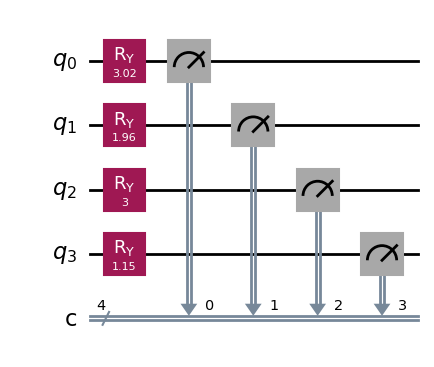

In [4]:
# INDEPENDENT CIRCUIT:
import numpy as np
thetas = np.random.uniform(0, np.pi, size=4)
qc_ind = build_circuit_independent(thetas,measure=True)
qc_ind.draw('mpl')

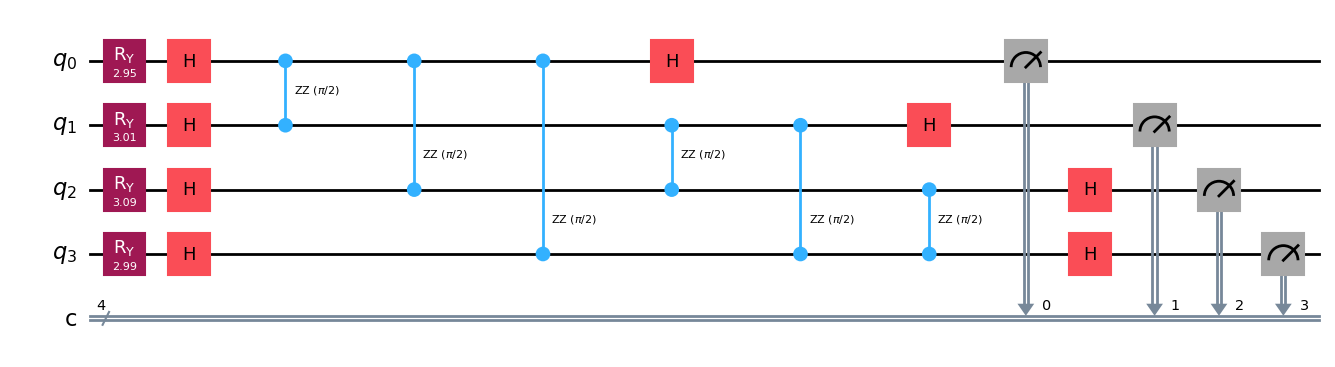

In [5]:
# RZZ CIRCUIT:
thetas = np.random.uniform(0, np.pi, size=4)
qc_rzz = build_correlated_circuit(thetas,theta_rzz=np.pi/2,measure=True)
qc_rzz.draw('mpl')

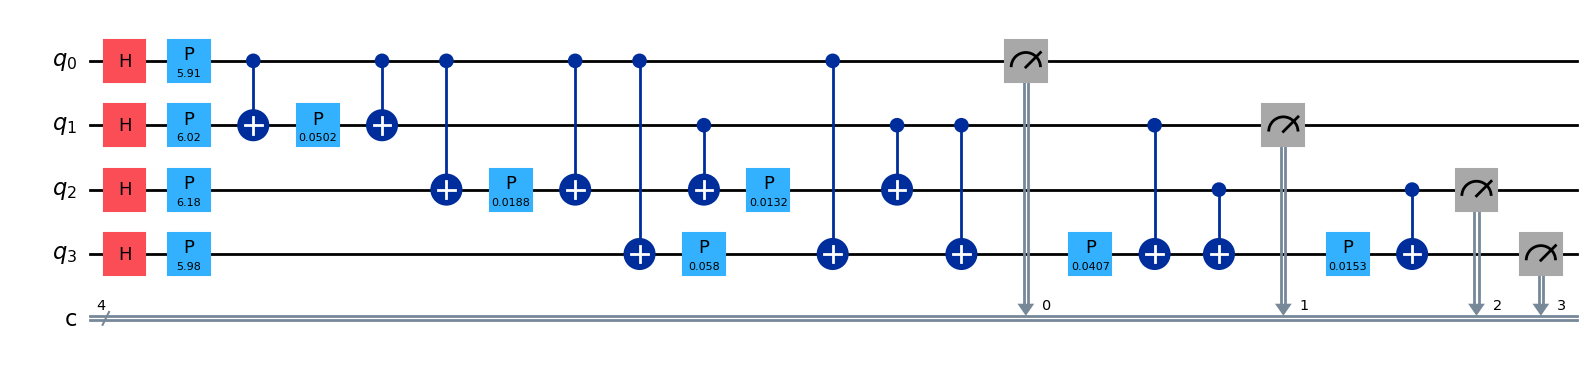

In [6]:
# ZZ FeatureMap CIRCUIT:
# from qiskit.circuit.library import zz_feature_map
qc_zzfm = build_zzfeaturemap_circuit(thetas,reps=1,entanglement="full", measure=True)
qc_zzfm.draw('mpl')

In [7]:
# qc.append(zz_feature_map(2,1),[0,1])
# qc.decompose().draw('mpl')
# qc.assign_parameters({qc.parameters[0]: 0.5, qc.parameters[1]: 0.5})

In [8]:
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError
from qiskit import transpile
from qiskit.circuit import QuantumCircuit
qc = QuantumCircuit(4,4)
qc.measure([0,1,2,3],[0,1,2,3])
noise_model = create_noise_model(
    mode="experimental_correlated")

sim = AerSimulator(noise_model=noise_model)
qc_t = transpile(qc,sim,optimization_level=0,
    initial_layout=[0,1,2,3])
result = sim.run(qc_t,shots=100000).result()

counts = result.get_counts()

print(counts)

{'0000': 100000}


In [9]:
qc = QuantumCircuit(4,4)
qc.measure([0,1,2,3],[0,1,2,3])

sim = AerSimulator()

qc_t = transpile(qc, sim)

result = sim.run(qc_t, shots=100000).result()

counts = result.get_counts()

p_ideal = counts_to_probs_4q(counts)

print("Ideal:")
print(p_ideal)

p_noisy = apply_correlated_readout_noise(p_ideal)

print("\nNoisy:")
print(np.round(p_noisy,3))

Ideal:
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Noisy:
[0.626 0.126 0.059 0.008 0.066 0.009 0.008 0.001 0.063 0.018 0.008 0.001
 0.003 0.002 0.001 0.001]


#### Base Functions:

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import zz_feature_map
# ============================================================
# INDEPENDENT CIRCUIT
def build_circuit_independent(thetas,measure=True,**kwargs):
    qc = QuantumCircuit(4, 4)
    for i in range(4):
        qc.ry(thetas[i], i)
    if measure:
        qc.measure([0,1,2,3], [0,1,2,3])
    return qc
# ============================================================
# RZZ CORRELATED CIRCUIT
def build_correlated_circuit(
    thetas,theta_rzz=np.pi/2,measure=True,**kwargs):
    qc = QuantumCircuit(4, 4)
    # amplitude encoding
    for i in range(4):
        qc.ry(thetas[i], i)
    # basis rotation
    for i in range(4):
        qc.h(i)
    # entangling layer
    for j in range(4):
        for k in range(j+1, 4):
            qc.rzz(theta_rzz, j, k)
    # return basis
    for i in range(4):
        qc.h(i)
    if measure:
        qc.measure([0,1,2,3], [0,1,2,3])
    return qc
# ============================================================
# ZZ FEATURE MAP CIRCUIT
def build_zzfeaturemap_circuit(
    thetas,reps=1,entanglement="full", measure=True, **kwargs):
    feature_map = zz_feature_map(feature_dimension=4,
        reps=reps,entanglement=entanglement)
    qc = QuantumCircuit(4, 4)
    qc.compose(feature_map.assign_parameters(thetas),inplace=True )
    if measure:
        qc.measure([0,1,2,3], [0,1,2,3])
    return qc

In [ ]:
import os
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError
from qiskit import transpile
# GLOBAL CONFIG
# ============================================================
NUM_QUBITS = 4
DATA_ROOT = "./DataTrain"
# CIRCUIT REGISTRY
CIRCUIT_BUILDERS = {"independent": build_circuit_independent,
    "zz_featuremap": build_zzfeaturemap_circuit,}
# ============================================================
# NOISE MODEL REGISTRY
NOISE_MODES = {"synthetic","experimental_single","experimental_correlated"}
# ============================================================
# CREATE NOISE MODEL
def create_noise_model(mode="synthetic",p01=0.05,p10=0.05,
    single_qubit_dir="./noise_matrix_results",
    correlated_matrix_path="./noise_matrix_results/noise_matrix_16x16.txt"):
    """Create noise model.
    synthetic:
        Same readout error on all qubits.
    experimental_single:
        Uses independent 2x2 assignment matrices
        extracted from experimental data.
    experimental_correlated:
        Uses full correlated 16x16 readout matrix. """
    noise_model = NoiseModel()
    # SYNTHETIC
    if mode == "synthetic":
        readout_error = ReadoutError([[1-p01, p01],
                                      [p10, 1-p10] ])
        for q in range(NUM_QUBITS):
            noise_model.add_readout_error(readout_error,[q] )
    # EXPERIMENTAL SINGLE-QUBIT
    elif mode == "experimental_single":
        for q in range(NUM_QUBITS):
            path = os.path.join(single_qubit_dir,
                f"assignment_matrix_q{q+1}.txt")
            A = np.loadtxt(path)
            readout_error = ReadoutError(A)
            noise_model.add_readout_error(readout_error,[q])
    # EXPERIMENTAL CORRELATED
    # elif mode == "experimental_correlated":   # Aer simulator only applu on single qubit readout error, 
    #     A16 = np.load(correlated_matrix_path) # so we cannot use the full 16x16 matrix directly.
    #     readout_error = ReadoutError(A16)
    #     noise_model.add_readout_error(readout_error,[0,1,2,3])
    elif mode == "experimental_correlated":
        # handled manually
        return None
    else:
        raise ValueError(f"Unknown noise mode: {mode}")
    return noise_model
# APPLY CORRELATED READOUT NOISE
# ============================================================
def apply_correlated_readout_noise(p_ideal,
    correlated_matrix_path="./noise_matrix_results/noise_matrix_16x16.txt"):
    """Apply correlated 16x16 readout assignment matrix.
    A[i,j] = P(measured=j | prepared=i)
    Therefore:
    p_noisy = p_ideal @ A    """
    A16 = np.loadtxt(correlated_matrix_path)
    p_noisy = p_ideal @ A16
    return p_noisy
# COUNTS -> PROBABILITIES
# ============================================================
def counts_to_probs_4q(counts):
    probs = np.zeros(16)
    for bitstring, count in counts.items():
        probs[int(bitstring, 2)] = count
    return probs / np.sum(probs)
# RUN CIRCUIT
# ============================================================
def get_probs(circuit_builder,thetas,noise_model=None,
    shots=1024,**circuit_kwargs):
    qc = circuit_builder(thetas,**circuit_kwargs)
    sim = AerSimulator(noise_model=noise_model)
    qc_t = transpile(qc, sim)
    result = sim.run(qc_t,shots=shots).result()
    counts = result.get_counts()
    return counts_to_probs_4q(counts)
# GENERATE DATASET
# ============================================================
def generate_dataset(num_samples,circuit_type="independent",
    noise_mode="synthetic",shots=1024,noise_kwargs=None,circuit_kwargs=None):
    """ Generate dataset.
    INPUT:
    circuit_type:
        independent
        zz_featuremap
        # zz_rzz
    noise_mode:
        synthetic
        experimental_single
        experimental_correlated """
    if noise_kwargs is None:
        noise_kwargs = {}
    if circuit_kwargs is None:
        circuit_kwargs = {}
    if circuit_type not in CIRCUIT_BUILDERS:
        raise ValueError("Unknown circuit type")
    circuit_builder = CIRCUIT_BUILDERS[circuit_type]
    X, Y, THETAS  = [], [], []
    for _ in range(num_samples):
        thetas = np.random.uniform(0,np.pi, size=NUM_QUBITS )   ######
        # thetas = np.random.uniform(0,np.pi/4, size=NUM_QUBITS )
        # CREATE NOISE MODEL
        # --------------------------------------------
        if noise_mode == "synthetic":
            p01 = np.random.uniform(noise_kwargs.get("p01_min", 0.05),
                noise_kwargs.get("p01_max", 0.15))
            p10 = np.random.uniform(noise_kwargs.get("p10_min", 0.05),
                noise_kwargs.get("p10_max", 0.15) )
            noise_model = create_noise_model(mode="synthetic", p01=p01,p10=p10)
        else:
            noise_model = create_noise_model(mode=noise_mode)
        # IDEAL
        # --------------------------------------------
        p_ideal = get_probs(circuit_builder,thetas,
            noise_model=None,shots=shots,**circuit_kwargs)      
        # NOISY
        # --------------------------------------------
        if noise_mode == "experimental_correlated":
            p_noisy = apply_correlated_readout_noise(p_ideal )
        else:
            p_noisy = get_probs(circuit_builder,thetas,
             noise_model=noise_model,shots=shots,**circuit_kwargs )
        X.append(p_noisy)
        Y.append(p_ideal)
        THETAS.append(thetas)
    return (np.array(X),np.array(Y), np.array(THETAS))
# SAVE DATASET
# ============================================================
def save_dataset(X,Y,THETAS,split="train",
    circuit_type="independent",noise_mode="synthetic"):
    """ Save dataset to:
     DataTrain/
        circuit_type/
            noise_mode/ """
    save_dir = os.path.join(DATA_ROOT,circuit_type, noise_mode)
    os.makedirs(save_dir, exist_ok=True)
    np.savetxt(os.path.join(save_dir, f"X_{split}.txt"),X)
    np.savetxt(os.path.join(save_dir, f"Y_{split}.txt"),Y )
    np.savetxt(os.path.join(save_dir, f"theta_{split}.txt"),THETAS)
    print("\nSaved dataset:")
    print(save_dir)
# LOAD DATASET
# ============================================================
def load_dataset(split="train",circuit_type="independent",
    noise_mode="synthetic"):
    load_dir = os.path.join(DATA_ROOT,circuit_type,noise_mode)
    X = np.loadtxt(os.path.join(load_dir, f"X_{split}.txt"))
    Y = np.loadtxt(os.path.join(load_dir, f"Y_{split}.txt"))
    THETAS = np.loadtxt(os.path.join(load_dir, f"theta_{split}.txt"))
    return X, Y, THETAS
# BUILD + SAVE DATASET
# ============================================================
def build_and_save_dataset(
    num_samples,split="train",circuit_type="independent",
    noise_mode="synthetic",shots=1024,noise_kwargs=None,
    circuit_kwargs=None):
    print("GENERATING DATASET")
    print("================================================")
    print("Circuit :", circuit_type)
    print("Noise   :", noise_mode)
    print("Samples :", num_samples)
    X, Y, THETAS = generate_dataset(
        num_samples=num_samples,
        circuit_type=circuit_type,
        noise_mode=noise_mode,
        shots=shots,noise_kwargs=noise_kwargs,
        circuit_kwargs=circuit_kwargs)
    save_dataset(X,Y,THETAS,
        split=split,circuit_type=circuit_type,noise_mode=noise_mode)
    return X, Y, THETAS

##### Evaluate Model

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
# Metrices 
def kl_divergence(p, q):
    return np.sum(p * np.log((p + 1e-10)/(q + 1e-10)))
def fidelity(p, q):
    return (np.sum(np.sqrt(p*q)))**2
def l1_error(p, q):
    return np.sum(np.abs(p-q))
def evaluate_model(model, X, Y):
    model.eval()
    fids,l1s, kls  = [], [], []
    with torch.no_grad():
        preds = model(
            torch.tensor(X, dtype=torch.float32)).numpy()
        # log_preds = model(
        #     torch.tensor(X, dtype=torch.float32)).numpy()
        # preds = torch.exp(preds).numpy()
    for pred, true in zip(preds, Y):
        fids.append(fidelity(true, pred))
        l1s.append(l1_error(true, pred))
        kls.append(kl_divergence(true, pred))
    return {"fidelity_mean": np.mean(fids),
        "fidelity_std":  np.std(fids),
        "l1_mean": np.mean(l1s),
        "l1_std":  np.std(l1s),
        "kl_mean": np.mean(kls),
        "kl_std":  np.std(kls),
        "all_fidelities": np.array(fids),
        "all_l1": np.array(l1s),
        "all_kl": np.array(kls) }

# 4 Qubits

## Baseline 

#### CIRCUITS

- I generated these datasets:
    - independent circuit with all three noise modes: synthetic, exprimental single and correlated
    - zzfeaturmap circuit with all noises. 


### Phase 0 
<!-- prediction = X_noisy
target     = Y_ideal -->


Identity Model

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
class IdentityModel(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return x
model_base = IdentityModel()

In [21]:
# # measure destroy power of each noise!
results_0 = {}
noise_modes = ["synthetic","experimental_single",
    "experimental_correlated"]
for noise_mode in noise_modes:
    X_test, Y_test, TH_test = load_dataset(
        split="test",
        circuit_type="independent",
        noise_mode=noise_mode)
    # EVALUATE
    results_0[noise_mode] = evaluate_model(
        model_base,X_test, Y_test)        # model base!
import pandas as pd
summary = []
for noise_mode, metrics in results_0.items():
    summary.append({
        "Noise": noise_mode,
        "Fidelity Mean":
            f"{metrics['fidelity_mean']:<0.3f}",
        "L1 Mean":
            f"{metrics['l1_mean']:<0.3f}",
        "KL Mean":
            f"{metrics['kl_mean']:<0.3f}"})
df_0 = pd.DataFrame(summary)
print("phase 0 (no training): Ry circuit(Independent), Test on all noise types")
print("=======================================================================")
print(df_0)

phase 0 (no training): Ry circuit(Independent), Test on all noise types
                     Noise Fidelity Mean L1 Mean KL Mean
0                synthetic         0.907   0.367   0.137
1      experimental_single         0.768   0.707   0.386
2  experimental_correlated         0.763   0.714   0.398


### Phase 1
<!-- - TRAIN:
    - independent + synthetic

- VALIDATION:
    - independent + synthetic

- TEST:
    - independent + all noises     -->

Train on independent circuit -Ry- using synthetic noise models and test on all noises.

In [6]:
X_train_1, Y_train_1, TH_train_1 = load_dataset(
    split="train",circuit_type="independent",
    noise_mode="synthetic")
X_val_1, Y_val_1, TH_val_1 = load_dataset(
    split="validation",circuit_type="independent",
    noise_mode="synthetic")
# Test — synthetic
X_test_syn_1, Y_test_syn_1, TH_test_syn_1 = load_dataset(
    split="test",circuit_type="independent",
    noise_mode="synthetic")
# Test — experimental single
X_test_single_1, Y_test_single_1, TH_test_single_1 = load_dataset(
    split="test",circuit_type="independent",
    noise_mode="experimental_single")
# Test — experimental correlated
X_test_corr_1, Y_test_corr_1, TH_test_corr_1 = load_dataset(
    split="test",circuit_type="independent",
    noise_mode="experimental_correlated")

##### TEST fidelity befor TRAINING

In [ ]:
# Fidelity before executing the training! 
raw_fidelity = np.mean([
    fidelity(Y_test_syn_1[i], X_test_syn_1[i])
    for i in range(len(X_test_syn_1))])
print(raw_fidelity)
raw_fidelity = np.mean([
    fidelity(Y_test_single_1[i], X_test_single_1[i])
    for i in range(len(X_test_syn_1))])

print(raw_fidelity)
raw_fidelity = np.mean([
    fidelity(Y_test_corr_1[i], X_test_corr_1[i])
    for i in range(len(X_test_syn_1))])
print(raw_fidelity)

0.9072323893272527
0.7676126563131969
0.7628629197344488


In [9]:
Y_train_1[1000]

array([0.02148438, 0.08886719, 0.        , 0.00292969, 0.04199219,
       0.25292969, 0.00097656, 0.01855469, 0.02246094, 0.12890625,
       0.00292969, 0.00195312, 0.05859375, 0.34277344, 0.00390625,
       0.01074219])

In [16]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_1, dtype=torch.float32),
        torch.tensor(Y_train_1, dtype=torch.float32)),
        batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_1, dtype=torch.float32),
        torch.tensor(Y_val_1, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=False)

In [11]:
import torch
import torch.nn as nn
class MLP_4Q(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 16),
            nn.Softmax(dim=1)
            # nn.LogSoftmax(dim=1)
              )
    def forward(self, x):
        return self.net(x)

In [12]:
model_phase1 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase1.parameters(),
    lr=1e-3)
EPOCHS = 51
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase1.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase1(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase1.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase1(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.8614 | Val Loss = 0.1717
Epoch 10 | Train Loss = 0.0454 | Val Loss = 0.0460
Epoch 20 | Train Loss = 0.0355 | Val Loss = 0.0379
Epoch 30 | Train Loss = 0.0344 | Val Loss = 0.0351
Epoch 40 | Train Loss = 0.0330 | Val Loss = 0.0345
Epoch 50 | Train Loss = 0.0331 | Val Loss = 0.0343


In [16]:
# # Plot 
# plt.figure(figsize=(4,2))
# plt.plot(train_losses, label="Train")
# plt.plot(val_losses,
#          label="Validation Experimental Single")
# plt.xlabel("Epoch")
# plt.ylabel("KL Loss")
# plt.title("Training Curve (Circuit: Ind, Noise: Synthetic)")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [17]:
results_1 = {}
results_1["synthetic"] = evaluate_model(
    model_phase1,X_test_syn_1,Y_test_syn_1)
results_1["experimental_single"] = evaluate_model(
    model_phase1,X_test_single_1,Y_test_single_1)
results_1["experimental_correlated"] = evaluate_model(
    model_phase1, X_test_corr_1, Y_test_corr_1)
import pandas as pd
rows = []
for name, res in results_1.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_1 = pd.DataFrame(rows)
print('==========================================================')
print("phase 1 (training): circuit: Independent, Noise: Synthetic")
print(df_1)

phase 1 (training): circuit: Independent, Noise: Synthetic
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.979    0.146    0.034
1      experimental_single         0.843    0.547    0.254
2  experimental_correlated         0.836    0.564    0.270


#### Phase 2

phase 2_0:
Ry Circuit and train experimental single!

In [ ]:
X_train_2, Y_train_2, TH_train_2 = load_dataset(
    split="train",circuit_type="independent",
    noise_mode="experimental_single")
X_val_2, Y_val_2, TH_val_2 = load_dataset(
    split="validation",circuit_type="independent",
    noise_mode="experimental_single")
# Test — synthetic
# As above for independent circuit

In [22]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_2, dtype=torch.float32),
        torch.tensor(Y_train_2, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_2, dtype=torch.float32),
        torch.tensor(Y_val_2, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [23]:
model_phase2_0 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase2_0.parameters(),
    lr=1e-3)
EPOCHS = 51
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase2_0.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase2_0(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase2_0.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase2_0(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.9425 | Val Loss = 0.3254
Epoch 10 | Train Loss = 0.0585 | Val Loss = 0.0582
Epoch 20 | Train Loss = 0.0555 | Val Loss = 0.0562
Epoch 30 | Train Loss = 0.0524 | Val Loss = 0.0520
Epoch 40 | Train Loss = 0.0495 | Val Loss = 0.0479
Epoch 50 | Train Loss = 0.0409 | Val Loss = 0.0400


In [24]:
# # Plot 
# plt.figure(figsize=(4,2))
# plt.plot(train_losses, label="Train")
# plt.plot(val_losses,
#          label="Validation Experimental Single")
# plt.xlabel("Epoch")
# plt.ylabel("KL Loss")
# plt.title("Training Curve (Circuit: Ry, Noise: Synthetic)")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [24]:
results_2 = {}
results_2["synthetic"] = evaluate_model(
    model_phase2_0,X_test_syn_1,Y_test_syn_1)
results_2["experimental_single"] = evaluate_model(
    model_phase2_0,X_test_single_1,Y_test_single_1)
results_2["experimental_correlated"] = evaluate_model(
    model_phase2_0, X_test_corr_1, Y_test_corr_1)
import pandas as pd
rows = []
for name, res in results_2.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_2_0 = pd.DataFrame(rows)
print("phase 2_0: circuit Independent, Noise: Single")
print('==========================================================')
print(df_2_0)

phase 2_0: circuit Independent, Noise: Single
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.886    0.433    0.340
1      experimental_single         0.974    0.162    0.040
2  experimental_correlated         0.969    0.183    0.051


##### phase 2_1:
Ry Circuit and train correlated datasets!

In [25]:
X_train_2_1, Y_train_2_1, TH_train_2_1 = load_dataset(
    split="train",circuit_type="independent",
    noise_mode="experimental_correlated")
X_val_2_1, Y_val_2_1, TH_val_2_1 = load_dataset(
    split="validation",circuit_type="independent",
    noise_mode="experimental_correlated")
# Test — synthetic
# AS sam as above for ind circuit

In [26]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_2_1, dtype=torch.float32),
        torch.tensor(Y_train_2_1, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_2_1, dtype=torch.float32),
        torch.tensor(Y_val_2_1, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [27]:
model_phase2_1 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase2_1.parameters(),
    lr=1e-3)
EPOCHS = 51
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase2_1.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase2_1(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase2_1.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase2_1(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.9684 | Val Loss = 0.4213
Epoch 10 | Train Loss = 0.0510 | Val Loss = 0.0530
Epoch 20 | Train Loss = 0.0466 | Val Loss = 0.0485
Epoch 30 | Train Loss = 0.0397 | Val Loss = 0.0428
Epoch 40 | Train Loss = 0.0342 | Val Loss = 0.0378
Epoch 50 | Train Loss = 0.0275 | Val Loss = 0.0279


In [28]:
results_2_1 = {}
results_2_1["synthetic"] = evaluate_model(
    model_phase2_1,X_test_syn_1,Y_test_syn_1)
results_2_1["experimental_single"] = evaluate_model(
    model_phase2_1,X_test_single_1,Y_test_single_1)
results_2_1["experimental_correlated"] = evaluate_model(
    model_phase2_1, X_test_corr_1, Y_test_corr_1)
import pandas as pd
rows = []
for name, res in results_2_1.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_2_1 = pd.DataFrame(rows)
print("phase 2_1: circuit Independent, Noise: correlated")
print('==========================================================')
print(df_2_1)

phase 2_1: circuit Independent, Noise: correlated
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.872    0.482    0.374
1      experimental_single         0.966    0.210    0.061
2  experimental_correlated         0.981    0.122    0.027


#### Phase 3_0 
- TRAIN:
    - zzfeaturemap + experimental_single  


- VALIDATION:
    - zzfeaturemap + experimental_single

- TEST:
    - zzfeaturemap + experimental_single
    - zzfeaturemap + experimental_correlated 
    - independent  + synthetic 

In [ ]:
X_train_3, Y_train_3, TH_train_3 = load_dataset(
    split="train",circuit_type="zz_featuremap",
    noise_mode="experimental_single")
X_val_3, Y_val_3, TH_val_3 = load_dataset(
    split="validation",circuit_type="zz_featuremap",
    noise_mode="experimental_single")
# Test 
X_test_syn_3, Y_test_syn_3, TH_test_syn_3 = load_dataset(
    split="test", circuit_type="independent",
    noise_mode="synthetic")
X_test_single_3, Y_test_single_3, TH_test_single_3 = load_dataset(
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single")
X_test_corr_3, Y_test_corr_3, TH_test_corr_3 = load_dataset(
    split="test",circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [30]:
# Fidelity before executing the training! 
raw_fidelity = np.mean([
    fidelity(Y_test_syn_3[i], X_test_syn_3[i])
    for i in range(len(X_test_syn_3))])
print(raw_fidelity)
raw_fidelity = np.mean([
    fidelity(Y_test_single_3[i], X_test_single_3[i])
    for i in range(len(X_test_single_3))])

print(raw_fidelity)
raw_fidelity = np.mean([
    fidelity(Y_test_corr_3[i], X_test_corr_3[i])
    for i in range(len(X_test_corr_3))])
print(raw_fidelity)

0.9072323893272527
0.9717056869260308
0.9732555074674157


In [31]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_3, dtype=torch.float32),
        torch.tensor(Y_train_3, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)

val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_3, dtype=torch.float32),
        torch.tensor(Y_val_3, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [32]:
model_phase3_0 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase3_0.parameters(),
    lr=1e-3)
EPOCHS = 51
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase3_0.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase3_0(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase3_0.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase3_0(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.0074 | Val Loss = 0.0074
Epoch 10 | Train Loss = 0.0074 | Val Loss = 0.0074
Epoch 20 | Train Loss = 0.0074 | Val Loss = 0.0074
Epoch 30 | Train Loss = 0.0073 | Val Loss = 0.0074
Epoch 40 | Train Loss = 0.0074 | Val Loss = 0.0074
Epoch 50 | Train Loss = 0.0074 | Val Loss = 0.0074


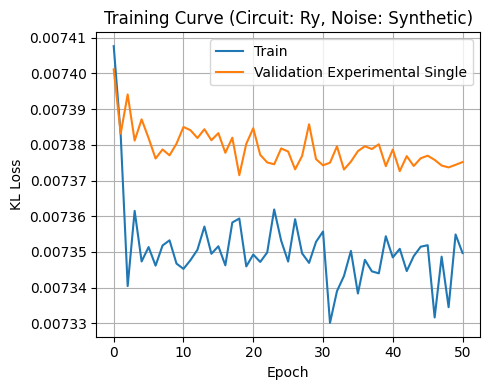

In [24]:
# Plot 
plt.figure(figsize=(5,4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses,
         label="Validation Experimental Single")
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.title("Training Curve (Circuit: Ry, Noise: Synthetic)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
results_3 = {}
results_3["synthetic"] = evaluate_model(
    model_phase3_0,X_test_syn_3,Y_test_syn_3)
results_3["experimental_single"] = evaluate_model(
    model_phase3_0,X_test_single_3,Y_test_single_3)
results_3["experimental_correlated"] = evaluate_model(
    model_phase3_0, X_test_corr_3, Y_test_corr_3)
import pandas as pd
rows = []
for name, res in results_3.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_3_0 = pd.DataFrame(rows)
print("phase 3_0: circuit zz, Noise: single")
print('==========================================================')
print(df_3_0)

phase 3_0: circuit zz, Noise: single
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.426    1.285    1.258
1      experimental_single         0.996    0.096    0.007
2  experimental_correlated         0.996    0.097    0.007


In [26]:
# How to explain the above strange results! check the leakage data?
np.mean(np.abs(X_train_3 - Y_train_3))
# np.mean(np.abs(X_test_single_3 - Y_test_single_3))

np.float64(0.017084391276041666)

In [27]:
# if the noise even excecuted?
thetas = np.random.uniform(0,np.pi,4)

p_ideal = get_probs(
    build_zzfeaturemap_circuit,
    thetas,
    noise_model=None
)

p_noisy = get_probs(
    build_zzfeaturemap_circuit,
    thetas,
    noise_model=create_noise_model(
        mode="experimental_single"
    )
)

print(fidelity(p_ideal,p_noisy))
print(np.max(np.abs(p_ideal-p_noisy)))

0.9679252763383527
0.0576171875


In [30]:
idx = np.random.randint(len(X_test_single_3))

print(Y_test_single_3[idx])
print("----")
print(X_test_single_3[idx])

print(fidelity(Y_test_single_3[idx], X_test_single_3[idx]))

[0.06542969 0.05957031 0.05175781 0.06347656 0.06152344 0.06445312
 0.05957031 0.06054688 0.05859375 0.06347656 0.0703125  0.06835938
 0.06347656 0.05761719 0.06347656 0.06835938]
----
[0.1015625  0.07617188 0.09765625 0.05371094 0.07226562 0.05761719
 0.05175781 0.06054688 0.07910156 0.07226562 0.046875   0.05078125
 0.06054688 0.03613281 0.046875   0.03613281]
0.9723179934157079


In [31]:
# check fidelity without traing
fids_raw = []

for i in range(len(X_test_single_3)):
    fids_raw.append(fidelity(Y_test_single_3[i],X_test_single_3[i] ))

print(np.mean(fids_raw))

0.9717056869260308


In [ ]:
# Fidelity before executing the training! 
raw_fidelity = np.mean([
    fidelity(Y_test_single_3[i], X_test_single_3[i])
    for i in range(len(X_test_single_3))])

print(raw_fidelity)

0.9717056869260308


In [34]:
print(np.mean(np.max(Y_test_single_3, axis=1)))
print(np.mean(np.max(X_test_single_3, axis=1)))

0.07653971354166667
0.10729296875


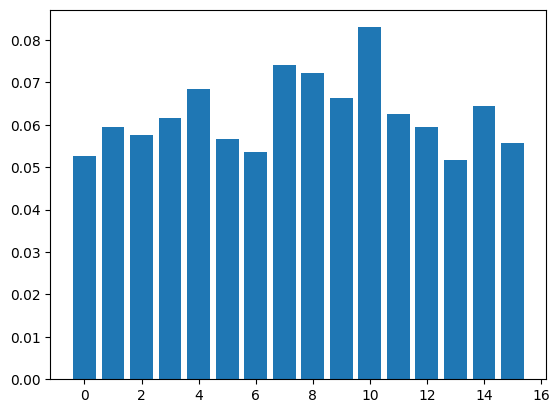

In [35]:
idx = np.random.randint(len(Y_test_single_3))

plt.bar(range(16), Y_test_single_3[idx])
plt.show()

In [37]:
purity_ind = np.mean([np.sum(y**2) for y in Y_test_syn_1])
print("purity_ind",purity_ind)

purity_zz = np.mean([np.sum(y2**2) for y2 in Y_test_corr_3])
print("purity_zz",purity_zz)

purity_ind 0.323609567006429
purity_zz 0.06341577529907226


In [ ]:
model_phase3_0 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase3_0.parameters(),
    lr=1e-3)
EPOCHS = 51
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase3_0.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase3_0(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase3_0.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase3_0(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.0074 | Val Loss = 0.0074
Epoch 10 | Train Loss = 0.0073 | Val Loss = 0.0074
Epoch 20 | Train Loss = 0.0073 | Val Loss = 0.0074
Epoch 30 | Train Loss = 0.0074 | Val Loss = 0.0074
Epoch 40 | Train Loss = 0.0073 | Val Loss = 0.0074
Epoch 50 | Train Loss = 0.0073 | Val Loss = 0.0074


In [ ]:
model_phase3_0 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase3_0.parameters(),
    lr=1e-3)
EPOCHS = 51
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase3_0.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase3_0(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase3_0.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase3_0(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.0074 | Val Loss = 0.0074
Epoch 10 | Train Loss = 0.0073 | Val Loss = 0.0074
Epoch 20 | Train Loss = 0.0073 | Val Loss = 0.0074
Epoch 30 | Train Loss = 0.0074 | Val Loss = 0.0074
Epoch 40 | Train Loss = 0.0073 | Val Loss = 0.0074
Epoch 50 | Train Loss = 0.0073 | Val Loss = 0.0074


### Phase 3_1
- train:
    - zz_featuremap + experimental_correlated
- VALIDATION:
    - zzfeaturemap + experimental_single
- TEST:
    - zzfeaturemap + experimental_single
    - zzfeaturemap + experimental_correlated 
    - zzfeaturemap  + synthetic 


In [34]:
X_train_31, Y_train_31, TH_train_31 = load_dataset(
    split="train", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

X_val_31, Y_val_31, TH_val_31 = load_dataset(
    split="validation", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

X_test_single_31, Y_test_single_31, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_single")

X_test_corr_31, Y_test_corr_31, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

X_test_syn_31, Y_test_syn_31, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="synthetic")

In [35]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_31, dtype=torch.float32),
        torch.tensor(Y_train_31, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_31, dtype=torch.float32),
        torch.tensor(Y_val_31, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [36]:
model_phase3_1 = MLP_4Q()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model_phase3_1.parameters(),
    lr=1e-3)
EPOCHS = 51
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase3_1.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase3_1(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # VALIDATION
    # =====================================================
    model_phase3_1.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase3_1(xb)
            loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print( f"Epoch {epoch} | "
            f"Train Loss = {train_loss:.6f} | "
            f"Val Loss = {val_loss:.6f}"        )

Epoch 0 | Train Loss = 0.000058 | Val Loss = 0.000057
Epoch 10 | Train Loss = 0.000056 | Val Loss = 0.000055
Epoch 20 | Train Loss = 0.000042 | Val Loss = 0.000042
Epoch 30 | Train Loss = 0.000039 | Val Loss = 0.000039
Epoch 40 | Train Loss = 0.000034 | Val Loss = 0.000034
Epoch 50 | Train Loss = 0.000031 | Val Loss = 0.000031


In [37]:
results_31 = {}
results_31["synthetic"] = evaluate_model(
    model_phase3_1,X_test_syn_31,Y_test_syn_31)
results_31["experimental_single"] = evaluate_model(
    model_phase3_1,X_test_single_31,Y_test_single_31)
results_31["experimental_correlated"] = evaluate_model(   
    model_phase3_1, X_test_corr_31, Y_test_corr_31)
import pandas as pd
rows = []
for name, res in results_31.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_3_1 = pd.DataFrame(rows)
print("phase 3_1: circuit zz, Noise: correlated")
print('==========================================================')
print(df_3_1)

phase 3_1: circuit zz, Noise: correlated
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.976    0.257    0.050
1      experimental_single         0.989    0.166    0.022
2  experimental_correlated         0.998    0.070    0.004


### Generate and Save datasets

In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="synthetic")
# about 17 min

GENERATING DATASET
Circuit : independent
Noise   : synthetic
Samples : 4500


In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="experimental_single")
# Next
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="experimental_correlated")

GENERATING DATASET
Circuit : independent
Noise   : experimental_single
Samples : 4500

Saved dataset:
./DataTrain\independent\experimental_single


In [ ]:
# Next
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="experimental_correlated")

GENERATING DATASET
Circuit : independent
Noise   : experimental_correlated
Samples : 4500

Saved dataset:
./DataTrain\independent\experimental_correlated


In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

GENERATING DATASET
Circuit : zz_featuremap
Noise   : experimental_correlated
Samples : 4500

Saved dataset:
./DataTrain\zz_featuremap\experimental_correlated


In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single")

GENERATING DATASET
Circuit : zz_featuremap
Noise   : experimental_single
Samples : 4500

Saved dataset:
./DataTrain\zz_featuremap\experimental_single


In [ ]:
# TEST:
#     independent + experimental_single
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="independent",
    noise_mode="experimental_single")

In [ ]:
# Test 1
X_test_base, Y_test_base, TH_test_base = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="independent",
    noise_mode="synthetic")

GENERATING DATASET
Circuit : independent
Noise   : synthetic
Samples : 1500

Saved dataset:
./DataTrain\independent\synthetic


In [ ]:
# Test Done!
X_test_fmap, Y_test_fmap, TH_test_fmap = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 1,"entanglement": "full"})

GENERATING DATASET
Circuit : zz_featuremap
Noise   : experimental_correlated
Samples : 1500

Saved dataset:
./DataTrain\zz_featuremap\experimental_correlated


In [ ]:
# VALIDATION: Done!
#     independent + experimental_correlated
X_val2, Y_val2, TH_val2 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="independent",
    noise_mode="experimental_correlated")

GENERATING DATASET
Circuit : independent
Noise   : experimental_correlated
Samples : 1500

Saved dataset:
./DataTrain\independent\experimental_correlated


In [ ]:
# test Done!
# independent + experimental_correlated
X_test_B, Y_test_B, TH_test_B = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="independent",
    noise_mode="experimental_correlated")

GENERATING DATASET
Circuit : independent
Noise   : experimental_correlated
Samples : 1500

Saved dataset:
./DataTrain\independent\experimental_correlated


In [ ]:
# VALIDATION:
#     independent + experimental_single
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="independent",
    noise_mode="synthetic")

GENERATING DATASET
Circuit : independent
Noise   : synthetic
Samples : 1500

Saved dataset:
./DataTrain\independent\synthetic


In [ ]:
# here Done!
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

GENERATING DATASET
Circuit : zz_featuremap
Noise   : experimental_correlated
Samples : 4500

Saved dataset:
./DataTrain\zz_featuremap\experimental_correlated


In [ ]:
# done
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

GENERATING DATASET
Circuit : zz_featuremap
Noise   : experimental_correlated
Samples : 1500

Saved dataset:
./DataTrain\zz_featuremap\experimental_correlated


In [ ]:
# done
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

GENERATING DATASET
Circuit : zz_featuremap
Noise   : experimental_correlated
Samples : 1500

Saved dataset:
./DataTrain\zz_featuremap\experimental_correlated


In [29]:
# Done 
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

GENERATING DATASET
Circuit : zz_featuremap
Noise   : experimental_single
Samples : 4500

Saved dataset:
./DataTrain\zz_featuremap\experimental_single


In [ ]:
# here done
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

GENERATING DATASET
Circuit : zz_featuremap
Noise   : experimental_single
Samples : 1500

Saved dataset:
./DataTrain\zz_featuremap\experimental_single


In [ ]:
# done
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

GENERATING DATASET
Circuit : zz_featuremap
Noise   : experimental_single
Samples : 1500

Saved dataset:
./DataTrain\zz_featuremap\experimental_single


In [ ]:
# done
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="synthetic",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

GENERATING DATASET
Circuit : zz_featuremap
Noise   : synthetic
Samples : 4500

Saved dataset:
./DataTrain\zz_featuremap\synthetic


In [35]:
# Done
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="synthetic",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

GENERATING DATASET
Circuit : zz_featuremap
Noise   : synthetic
Samples : 1500

Saved dataset:
./DataTrain\zz_featuremap\synthetic


In [36]:
# next 
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="zz_featuremap",
    noise_mode="synthetic",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

GENERATING DATASET
Circuit : zz_featuremap
Noise   : synthetic
Samples : 1500

Saved dataset:
./DataTrain\zz_featuremap\synthetic


In [ ]:
# Generate diverse data set for zz_featuremap
# by parameters reps and theta range ---> reps: 1, 2 and theta range: [0, pi], [0, 2pi]

In [39]:
X_test_corr, Y_test_corr, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [40]:
purity_ind = np.mean([np.sum(y**2) for y in Y_test_syn_1])
print("purity_ind",purity_ind)

purity_zz = np.mean([np.sum(y2**2) for y2 in Y_test_corr])
print("purity_zz",purity_zz)

purity_ind 0.323609567006429
purity_zz 0.14086570358276368


In [ ]:
raw_fidelity = np.mean([
    fidelity(Y_test_corr2[i], X_test_corr2[i])
    for i in range(len(X_test_corr))])
print(raw_fidelity)

NameError: name 'X_test_corr' is not defined

In [43]:
# reps= 2 and theta range: [0, pi/4]
X_test_fmap, Y_test_fmap, TH_test_fmap = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

GENERATING DATASET
Circuit : zz_featuremap
Noise   : experimental_correlated
Samples : 1500

Saved dataset:
./DataTrain\zz_featuremap\experimental_correlated


In [44]:
X_test_corr2, Y_test_corr2, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [45]:
purity_ind = np.mean([np.sum(y**2) for y in Y_test_syn_1])
print("purity_ind",purity_ind)

purity_zz2 = np.mean([np.sum(y3**2) for y3 in Y_test_corr2])
print("purity_zz2",purity_zz2)

purity_ind 0.323609567006429
purity_zz2 0.13117073059082032


In [22]:
X_test_corr, Y_test_corr, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [23]:
raw_fidelity = np.mean([
    fidelity(Y_test_corr[i], X_test_corr[i])
    for i in range(len(X_test_corr))])
print(raw_fidelity)

0.8686581539651197


### Previouse Methods

In [59]:
# def plot_prediction_examples(model,X,Y,dataset_name, num_samples=1):
#     indices = np.random.choice(
#         len(X),size=num_samples,replace=False)
#     x_axis = np.arange(16)
#     width = 0.25
#     model.eval()
#     for idx in indices:
#         with torch.no_grad():
#             pred = model(torch.tensor(
#                     X[idx],dtype=torch.float32
#                 ).unsqueeze(0)).numpy().flatten()

#         fid = fidelity(Y[idx], pred)
#         plt.figure(figsize=(9,3))
#         plt.bar(x_axis - width,Y[idx],width=width,label="Ideal" )
#         plt.bar(x_axis,X[idx],width=width,alpha=0.5,label="Noisy" )
#         plt.bar(x_axis + width,pred, width=width,label="Predicted")

#         plt.title(f"{dataset_name} | Fidelity = {fid:.4f}" )
#         plt.xlabel("Basis State")
#         plt.ylabel("Probability")
#         plt.grid(True)
#         plt.legend()
#         plt.tight_layout()
#         plt.show()

In [45]:
# plot_prediction_examples(
#     model_base,
#     X_test_rzz,
#     Y_test_rzz,
#     dataset_name="RZZ Test")
# plot_prediction_examples(
#     model_base,
#     X_test_fmap,
#     Y_test_fmap,
#     dataset_name="ZZFeatureMap Test")

##### Save datasetsm

In [46]:
# # ================================
# # EVALUATION FUNCTION
# # ================================
# def evaluate_model(model, X, Y):
#     fids, l1s, kls = [], [], []
#     model.eval()
#     with torch.no_grad():
#         for i in range(len(X)):
#             pred = model(torch.tensor(X[i],dtype=torch.float32).unsqueeze(0)).numpy().flatten()
#             true = Y[i]
#             fids.append(fidelity(true,pred))
#             l1s.append(l1_error(true,pred))
#             kls.append(kl_divergence(true,pred))
#     return np.array(fids), np.array(l1s), np.array(kls)

# fids_ind, l1_ind, kl_ind = evaluate_model(model_base, X_test_ind, Y_test_ind)
# fids_zz, l1_zz, kl_zz = evaluate_model(model_base, X_test_zz, Y_test_zz)
# fids_mix, l1_mix, kl_mix = evaluate_model(model_base, X_test_combined, Y_test_combined)
# # RZZ Correlated: 
# # کاهش فضای حالت موثر
# # توزیع حالات تمرکز بیشتری پیدا می کند
# print("\n===== TEST METRICS =====\n")
# print(f"{'Dataset':<15} | {'Fidelity':<10} | {'L1 Error':<10} | {'KL Divergence':<12}")
# print("-"*58)
# print(f"{'Independent':<15} | {np.mean(fids_ind):<10.4f} | {np.mean(l1_ind):<10.4f} | {np.mean(kl_ind):<12.4f}")
# print(f"{'RZZ Correlated':<15} | {np.mean(fids_zz):<10.4f} | {np.mean(l1_zz):<10.4f} | {np.mean(kl_zz):<12.4f}")
# print(f"{'Combined':<15} | {np.mean(fids_mix):<10.4f} | {np.mean(l1_mix):<10.4f} | {np.mean(kl_mix):<12.4f}")

In [47]:
# # ================================
# # EVALUATION FUNCTION
# # ================================
# def evaluate_model(model, X, Y):
#     fids, l1s, kls = [], [], []
#     model.eval()
#     with torch.no_grad():
#         for i in range(len(X)):
#             pred = model(torch.tensor(X[i],dtype=torch.float32).unsqueeze(0)).numpy().flatten()
#             true = Y[i]
#             fids.append(fidelity(true,pred))
#             l1s.append(l1_error(true,pred))
#             kls.append(kl_divergence(true,pred))
#     return np.array(fids), np.array(l1s), np.array(kls)

# fids_ind, l1_ind, kl_ind = evaluate_model(model_base, X_test_ind, Y_test_ind)
# fids_zz, l1_zz, kl_zz = evaluate_model(model_base, X_test_zz, Y_test_zz)
# fids_mix, l1_mix, kl_mix = evaluate_model(model_base, X_test_combined, Y_test_combined)
# # RZZ Correlated: 
# # کاهش فضای حالت موثر
# # توزیع حالات تمرکز بیشتری پیدا می کند
# print("\n===== TEST METRICS =====\n")
# print(f"{'Dataset':<15} | {'Fidelity':<10} | {'L1 Error':<10} | {'KL Divergence':<12}")
# print("-"*58)
# print(f"{'Independent':<15} | {np.mean(fids_ind):<10.4f} | {np.mean(l1_ind):<10.4f} | {np.mean(kl_ind):<12.4f}")
# print(f"{'RZZ Correlated':<15} | {np.mean(fids_zz):<10.4f} | {np.mean(l1_zz):<10.4f} | {np.mean(kl_zz):<12.4f}")
# print(f"{'Combined':<15} | {np.mean(fids_mix):<10.4f} | {np.mean(l1_mix):<10.4f} | {np.mean(kl_mix):<12.4f}")

In [48]:
# import numpy as np
# import matplotlib.pyplot as plt
# import torch
# # تعداد نمونه‌هایی که می‌خواهیم نمایش دهیم
# num_samples_to_plot = 2
# indices = np.random.choice(len(X_test_combined), size=num_samples_to_plot, replace=False)
# x_axis = np.arange(16)
# width = 0.2

# for idx in indices:
#     # تعیین نوع نمونه
#     label_type = "Independent" if idx < 1000 else "RZZ Correlated"
#     plt.figure(figsize=(9,3))
#     # ستون‌های نمودار
#     plt.bar(x_axis - 1.5*width, Y_test_combined[idx], width=width, label=f"Ideal ({label_type})")
#     plt.bar(x_axis - 0.5*width, X_test_combined[idx], width=width, alpha=0.4, label=f"Noisy ({label_type})")
#     # پیش‌بینی مدل پایه
#     pred = model_base(torch.tensor(X_test_combined[idx], dtype=torch.float32).unsqueeze(0)).detach().numpy().flatten()
#     f = fidelity(Y_test_combined[idx], pred)
#     plt.bar(x_axis + 0.5*width, pred, width=width, label="Predicted (Base Model)")
#     plt.xlabel("State Index")
#     plt.ylabel("Probability")
#     plt.title(f"Sample {idx} | {label_type}| Fidelity {100*f:.4f} ")
#     plt.legend()
#     plt.grid()
#     plt.show()

In [49]:
# plt.figure(figsize=(5,3))
# plt.hist(fids_ind, bins=40)
# plt.title("Fidelity Distribution(ind)")
# plt.show()

In [50]:
# plt.figure(figsize=(5,3))
# plt.hist(fids_zz, bins=40)
# plt.title("Fidelity Distribution(zz)")
# plt.show()

In [51]:
# # ================================
# # EVALUATION METRICS vs Base Model
# # ================================
# def compute_metric_vs_theta(X, Y, theta_array, model, metric='fidelity', num_bins=20):
#     model.eval()
#     values, theta_mean_list = [], []
#     with torch.no_grad():
#         for i in range(len(X)):
#             x = torch.tensor(X[i],dtype=torch.float32).unsqueeze(0)
#             pred = model(x).numpy().flatten()
#             true = Y[i]
#             theta_mean = np.mean(theta_array[i])
#             theta_mean_list.append(theta_mean)
#             if metric=='fidelity':
#                 values.append(fidelity(true,pred))
#             elif metric=='kl':
#                 values.append(kl_divergence(true,pred))
#     theta_mean_list = np.array(theta_mean_list)
#     values = np.array(values)
#     bins = np.linspace(0,np.pi,num_bins)
#     bin_centers = 0.5*(bins[:-1]+bins[1:])
#     values_binned = []
#     for i in range(len(bins)-1):
#         mask = (theta_mean_list>=bins[i]) & (theta_mean_list<bins[i+1])
#         values_binned.append(np.mean(values[mask]) if np.any(mask) else np.nan)
#     return bin_centers, np.array(values_binned)
# # ================================
# # Fidelity comparison

# # محاسبه برای دیتاست مستقل
# # ================================
# bin_centers_ind, fid_binned_ind = compute_metric_vs_theta(X_test_ind, Y_test_ind, theta_test_ind, model_base, 'fidelity')
# # ================================
# # محاسبه برای دیتاست RZZ
# # ================================
# bin_centers_zz, fid_binned_zz = compute_metric_vs_theta(X_test_zz, Y_test_zz, theta_test_zz, model_base, 'fidelity')
# # ================================
# # محاسبه برای دیتاست ترکیبی combined
# # ================================
# bin_centers_mix,fid_binned_mix = compute_metric_vs_theta(X_test_combined, Y_test_combined, theta_test_combined, model_base, 'fidelity')
# # ================================
# # رسم نمودار مقایسه‌ای
# # ================================
# plt.figure(figsize=(6,4))
# plt.plot(bin_centers_ind, fid_binned_ind, marker='o', label="Independent Test")
# plt.plot(bin_centers_zz, fid_binned_zz, marker='s', label="RZZ Correlated Test")
# plt.plot(bin_centers_mix, fid_binned_mix, marker='v', label="Combined Test")
# plt.xlabel("Mean θ")
# plt.ylabel("Mean Fidelity")
# plt.title("Base Model | Fidelity vs Mean θ")
# plt.legend()
# plt.grid(True)
# plt.show()

In [52]:
# # ================================
# # محاسبه میانگین KL divergence بر اساس theta
# # ================================
# # ================================
# # محاسبه برای دیتاست مستقل
# # ================================
# bin_centers_ind, kl_binned_ind = compute_metric_vs_theta(
#     X_test_ind, Y_test_ind, theta_test_ind, model_base, 'kl')
# # ================================
# # محاسبه برای دیتاست RZZ
# # ================================
# bin_centers_zz, kl_binned_zz = compute_metric_vs_theta(
#     X_test_zz, Y_test_zz, theta_test_zz, model_base, 'kl')
# # ================================
# # محاسبه برای دیتاست ترکیبی combined
# # ================================
# bin_centers_mix, kl_binned_mix = compute_metric_vs_theta(
#     X_test_combined, Y_test_combined, theta_test_combined, model_base, 'kl')
# # ================================
# # رسم نمودار مقایسه‌ای KL
# # ================================
# plt.figure(figsize=(6,4))
# plt.plot(bin_centers_ind, kl_binned_ind, marker='o', label="Independent Test")
# plt.plot(bin_centers_zz, kl_binned_zz, marker='s', label="RZZ Correlated Test")
# plt.plot(bin_centers_mix, kl_binned_mix, marker='d', label="Combined Test")
# plt.xlabel("Mean θ")
# plt.ylabel("Mean KL Divergence")
# plt.title("Base model | KL Divergence vs Mean θ")
# plt.legend()
# plt.grid(True)
# plt.show()

###### Train / Validation / Test

In [53]:
# fids_ind_mlp, l1_ind_mlp, kl_ind_mlp = evaluate_model(model_mlp, X_test_ind, Y_test_ind)
# fids_zz_mlp, l1_zz_mlp, kl_zz_mlp = evaluate_model(model_mlp, X_test_zz, Y_test_zz)
# fids_mix_mlp, l1_mix_mlp, kl_mix_mlp = evaluate_model(model_mlp, X_test_combined, Y_test_combined)
# # RZZ Correlated: 
# # کاهش فضای حالت موثر
# # توزیع حالات تمرکز بیشتری پیدا می کند
# print("\n===== TEST METRICS_MLP =====\n")
# print(f"{'Dataset':<15} | {'Fidelity':<10} | {'L1 Error':<10} | {'KL Divergence':<12}")
# print("-"*58)
# print(f"{'Independent':<15} | {np.mean(fids_ind_mlp):<10.4f} | {np.mean(l1_ind_mlp):<10.4f} | {np.mean(kl_ind_mlp):<12.4f}")
# print(f"{'RZZ Correlated':<15} | {np.mean(fids_zz_mlp):<10.4f} | {np.mean(l1_zz_mlp):<10.4f} | {np.mean(kl_zz_mlp):<12.4f}")
# print(f"{'Combined':<15} | {np.mean(fids_mix_mlp):<10.4f} | {np.mean(l1_mix_mlp):<10.4f} | {np.mean(kl_mix_mlp):<12.4f}")

In [54]:
# num_samples_to_plot = 2
# indices = np.random.choice(len(X_test_combined), size=num_samples_to_plot, replace=False)

# x_axis = np.arange(16)
# width = 0.2

# for idx in indices:
#     # تعیین نوع نمونه
#     label_type = "Independent" if idx < len(X_test_ind) else "RZZ Correlated"
    
#     plt.figure(figsize=(9,3))
#     # ستون‌های نمودار
#     plt.bar(x_axis - 1.5*width, Y_test_combined[idx], width=width, label=f"Ideal ({label_type})")
#     plt.bar(x_axis - 0.5*width, X_test_combined[idx], width=width, alpha=0.4, label=f"Noisy ({label_type})")
    
#     # پیش‌بینی مدل MLP
#     pred = model_mlp(torch.tensor(X_test_combined[idx], dtype=torch.float32).unsqueeze(0)).detach().numpy().flatten()
#     f = fidelity(Y_test_combined[idx], pred)
    
#     plt.bar(x_axis + 0.5*width, pred, width=width, label="Predicted (MLP Model)")
#     plt.xlabel("State Index")
#     plt.ylabel("Probability")
#     plt.title(f"Sample {idx} | {label_type} | Fidelity {100*f:.4f}")
#     plt.legend()
#     plt.grid()
#     plt.show()

In [55]:
# fidelities, l1_errors, kl_values = [], [], []

# model_mlp.eval()
# with torch.no_grad():
#     for i in range(len(X_test_combined)):
#         pred = model_mlp(torch.tensor(X_test_combined[i], dtype=torch.float32).unsqueeze(0)).numpy().flatten()
#         true = Y_test_combined[i]

#         fidelities.append(fidelity(true, pred))
#         l1_errors.append(l1_error(true, pred))
#         kl_values.append(kl_divergence(true, pred))

# print("\n===== TEST METRICS =====")
# print("Avg Fidelity:", np.mean(fidelities))
# print("Avg L1:", np.mean(l1_errors))
# print("Avg KL:", np.mean(kl_values))

##### Compare model_base vs model_mlp

In [56]:
# ## ZZ data

# bin_zz_base, fid_zz_base = compute_metric_vs_theta(
#     X_test_zz, Y_test_zz, theta_test_zz, model_base, 'fidelity'
# )
# bin_zz_mlp, fid_zz_mlp = compute_metric_vs_theta(
#     X_test_zz, Y_test_zz, theta_test_zz, model_mlp, 'fidelity'
# )

# plt.figure(figsize=(6,4))
# plt.plot(bin_zz_base, fid_zz_base, marker='o', label="Base Model")
# plt.plot(bin_zz_mlp, fid_zz_mlp, marker='s', label="MLP Model")
# plt.xlabel("Mean θ")
# plt.ylabel("Mean Fidelity")
# plt.title("RZZ Correlated Test: Base vs MLP")
# plt.grid(True)
# plt.legend()
# plt.show()

In [57]:
# plt.figure(figsize=(8,5))

# # Base Model
# plt.plot(bin_ind_base, fid_ind_base, marker='o', linestyle='-', label="Base: Independent")
# plt.plot(bin_zz_base, fid_zz_base, marker='s', linestyle='-', label="Base: RZZ Correlated")
# plt.plot(bin_comb_base, fid_comb_base, marker='x', linestyle='-', label="Base: Combined")

# # MLP Model
# plt.plot(bin_ind_mlp, fid_ind_mlp, marker='o', linestyle='--', label="MLP: Independent")
# plt.plot(bin_zz_mlp, fid_zz_mlp, marker='s', linestyle='--', label="MLP: RZZ Correlated")
# plt.plot(bin_comb_mlp, fid_comb_mlp, marker='x', linestyle='--', label="MLP: Combined")

# plt.xlabel("Mean θ")
# plt.ylabel("Mean Fidelity")
# plt.title("Comparison of Base vs MLP Model across Test Datasets")
# plt.grid(True)
# plt.legend(loc="lower right", fontsize=9)
# plt.tight_layout()
# plt.show()

In [58]:
# # محاسبه متریک‌ها برای Base Model
# fids_ind_base, l1_ind_base, kl_ind_base = evaluate_model(model_base, X_test_ind, Y_test_ind)
# fids_zz_base, l1_zz_base, kl_zz_base = evaluate_model(model_base, X_test_zz, Y_test_zz)
# fids_mix_base, l1_mix_base, kl_mix_base = evaluate_model(model_base, X_test_combined, Y_test_combined)

# # محاسبه متریک‌ها برای MLP Model
# fids_ind_mlp, l1_ind_mlp, kl_ind_mlp = evaluate_model(model_mlp, X_test_ind, Y_test_ind)
# fids_zz_mlp, l1_zz_mlp, kl_zz_mlp = evaluate_model(model_mlp, X_test_zz, Y_test_zz)
# fids_mix_mlp, l1_mix_mlp, kl_mix_mlp = evaluate_model(model_mlp, X_test_combined, Y_test_combined)

# # نمایش جدول مقایسه‌ای
# print("\n===== COMPARISON: Base Model vs MLP Model =====\n")
# header = f"{'Dataset':<15} | {'Metric':<10} | {'Base Model':<12} | {'MLP Model':<12}"
# print(header)
# print("-"*len(header))

# datasets = ["Independent", "RZZ Correlated", "Combined"]
# metrics = ["Fidelity", "L1 Error", "KL Divergence"]

# for ds, f_base, f_mlp, l1_base, l1_mlp, kl_base, kl_mlp in zip(
#     datasets,
#     [np.mean(fids_ind_base), np.mean(fids_zz_base), np.mean(fids_mix_base)],
#     [np.mean(fids_ind_mlp), np.mean(fids_zz_mlp), np.mean(fids_mix_mlp)],
#     [np.mean(l1_ind_base), np.mean(l1_zz_base), np.mean(l1_mix_base)],
#     [np.mean(l1_ind_mlp), np.mean(l1_zz_mlp), np.mean(l1_mix_mlp)],
#     [np.mean(kl_ind_base), np.mean(kl_zz_base), np.mean(kl_mix_base)],
#     [np.mean(kl_ind_mlp), np.mean(kl_zz_mlp), np.mean(kl_mix_mlp)]
# ):
#     print(f"{ds:<15} | {metrics[0]:<13} | {f_base:<12.4f} | {f_mlp:<12.4f}")
#     print(f"{'':<15} | {metrics[1]:<13} | {l1_base:<12.4f} | {l1_mlp:<12.4f}")
#     print(f"{'':<15} | {metrics[2]:<13} | {kl_base:<12.4f} | {kl_mlp:<12.4f}")
#     print("-"*len(header))